<a href="https://colab.research.google.com/github/Sera2006-sudo/LAB-1/blob/main/resume%20screening%20sytstem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("AI_Resume_Screening.csv")

# Display first 5 rows
print(df.head())

# Check dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())

# Remove duplicate records
df = df.drop_duplicates()

# Fill missing values
df["Skills"] = df["Skills"].fillna("Unknown")
df["Education"] = df["Education"].fillna("Unknown")
df["Certifications"] = df["Certifications"].fillna("None")
df["Job Role"] = df["Job Role"].fillna("Unknown")

# Fill numerical missing values with median
df["Experience (Years)"] = df["Experience (Years)"].fillna(df["Experience (Years)"].median())
df["Salary Expectation ($)"] = df["Salary Expectation ($)"].fillna(df["Salary Expectation ($)"].median())
df["Projects Count"] = df["Projects Count"].fillna(df["Projects Count"].median())
df["AI Score (0-100)"] = df["AI Score (0-100)"].fillna(df["AI Score (0-100)"].median())

# Drop unnecessary columns
df = df.drop(columns=["Resume_ID", "Name"])

# Encode categorical columns
label_encoder = LabelEncoder()

categorical_columns = [
    "Skills",
    "Education",
    "Certifications",
    "Job Role",
    "Recruiter Decision"
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Display preprocessed dataset
print(df.head())

# Save preprocessed dataset
df.to_csv("Preprocessed_AI_Resume_Screening.csv", index=False)

print("Preprocessing completed successfully!")

   Resume_ID              Name                                        Skills  \
0          1        Ashley Ali                      TensorFlow, NLP, Pytorch   
1          2      Wesley Roman  Deep Learning, Machine Learning, Python, SQL   
2          3     Corey Sanchez         Ethical Hacking, Cybersecurity, Linux   
3          4  Elizabeth Carney                   Python, Pytorch, TensorFlow   
4          5        Julie Hill                              SQL, React, Java   

   Experience (Years) Education                Certifications  \
0                  10      B.Sc                           NaN   
1                  10       MBA                     Google ML   
2                   1       MBA  Deep Learning Specialization   
3                   7    B.Tech                 AWS Certified   
4                   4       PhD                           NaN   

                Job Role Recruiter Decision  Salary Expectation ($)  \
0          AI Researcher               Hire              

In [ ]:
from google.colab import files
uploaded = files.upload()  # select AI_Resume_Screening.csv when prompted

Saving AI_Resume_Screening.csv to AI_Resume_Screening (1).csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('AI_Resume_Screening.csv')
print(df.shape)
df.head()

(1000, 11)


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
print('Missing values:\n', df.isnull().sum())
print('\nDuplicate Resume_IDs:', df['Resume_ID'].duplicated().sum())
print('\nJob Role classes:\n', df['Job Role'].value_counts())

Missing values:
 Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

Duplicate Resume_IDs: 0

Job Role classes:
 Job Role
AI Researcher            257
Data Scientist           255
Cybersecurity Analyst    255
Software Engineer        233
Name: count, dtype: int64


In [ ]:
df['Certifications'] = df['Certifications'].fillna('None')
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,0
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [ ]:
import re

def clean_skills(text):
    text = text.lower()
    skills = [s.strip() for s in text.split(',')]
    return ', '.join(skills)

df['Skills_clean'] = df['Skills'].apply(clean_skills)
df['Skills_list'] = df['Skills_clean'].apply(lambda x: x.split(', '))
df[['Skills', 'Skills_clean', 'Skills_list']].head()

,Skills,Skills_clean,Skills_list
0,"TensorFlow, NLP, Pytorch","tensorflow, nlp, pytorch","[tensorflow, nlp, pytorch]"
1,"Deep Learning, Machine Learning, Python, SQL","deep learning, machine learning, python, sql","[deep learning, machine learning, python, sql]"
2,"Ethical Hacking, Cybersecurity, Linux","ethical hacking, cybersecurity, linux","[ethical hacking, cybersecurity, linux]"
3,"Python, Pytorch, TensorFlow","python, pytorch, tensorflow","[python, pytorch, tensorflow]"
4,"SQL, React, Java","sql, react, java","[sql, react, java]"


In [ ]:
# Quick look at most common individual skills across the dataset
from collections import Counter
all_skills = [s for row in df['Skills_list'] for s in row]
Counter(all_skills).most_common(15)

[('python', 388),
 ('sql', 370),
 ('ethical hacking', 206),
 ('tensorflow', 205),
 ('machine learning', 200),
 ('nlp', 195),
 ('linux', 191),
 ('pytorch', 189),
 ('java', 188),
 ('deep learning', 184),
 ('cybersecurity', 184),
 ('networking', 184),
 ('c++', 168),
 ('react', 165)]

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Target encoding
le_role = LabelEncoder()
df['Job_Role_encoded'] = le_role.fit_transform(df['Job Role'])
print(dict(zip(le_role.classes_, le_role.transform(le_role.classes_))))

{'AI Researcher': np.int64(0), 'Cybersecurity Analyst': np.int64(1), 'Data Scientist': np.int64(2), 'Software Engineer': np.int64(3)}


In [ ]:
# Education: ordinal mapping (lowest to highest)
edu_order = {'B.Sc': 0, 'B.Tech': 1, 'MBA': 2, 'M.Tech': 3, 'PhD': 4}
df['Education_encoded'] = df['Education'].map(edu_order)

# Certifications: one-hot encode
cert_dummies = pd.get_dummies(df['Certifications'], prefix='Cert')
df = pd.concat([df, cert_dummies], axis=1)

# Recruiter Decision: binary
df['Recruiter_Decision_binary'] = df['Recruiter Decision'].map({'Hire': 1, 'Reject': 0})

df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),Skills_clean,Skills_list,Job_Role_encoded,Education_encoded,Cert_AWS Certified,Cert_Deep Learning Specialization,Cert_Google ML,Cert_None,Recruiter_Decision_binary
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,None,AI Researcher,Hire,104895,8,100,"tensorflow, nlp, pytorch","[tensorflow, nlp, pytorch]",0,0,False,False,False,True,1
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100,"deep learning, machine learning, python, sql","[deep learning, machine learning, python, sql]",2,2,False,False,True,False,1
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,"ethical hacking, cybersecurity, linux","[ethical hacking, cybersecurity, linux]",1,2,False,True,False,False,1
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,"python, pytorch, tensorflow","[python, pytorch, tensorflow]",0,1,True,False,False,False,1
4,5,Julie Hill,"SQL, React, Java",4,PhD,None,Software Engineer,Hire,87441,9,100,"sql, react, java","[sql, react, java]",3,4,False,False,False,True,1


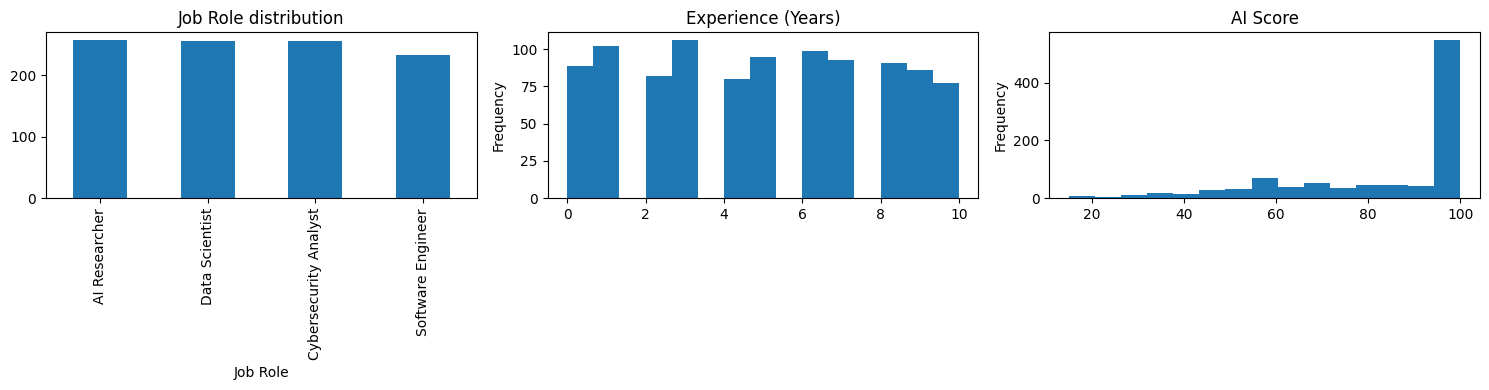

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Job Role'].value_counts().plot(kind='bar', ax=axes[0], title='Job Role distribution')
df['Experience (Years)'].plot(kind='hist', bins=15, ax=axes[1], title='Experience (Years)')
df['AI Score (0-100)'].plot(kind='hist', bins=15, ax=axes[2], title='AI Score')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

feature_cols = ['Skills_clean', 'Experience (Years)', 'Education_encoded',
                'Projects Count', 'AI Score (0-100)'] + list(cert_dummies.columns)

X = df[feature_cols]
y = df['Job_Role_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (800, 9)
Test shape: (200, 9)


In [ ]:
df.to_csv('AI_Resume_Screening_cleaned.csv', index=False)
from google.colab import files
files.download('AI_Resume_Screening_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import zipfile

with zipfile.ZipFile("resume screening system.zip", "r") as zip_ref:
    zip_ref.extractall()